In [4]:
import json
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import logging
import warnings
# Try importing pydub; it's often needed by librosa for MP3s,
# or you can use it to convert MP3 to WAV before librosa.load
try:
    from pydub import AudioSegment
except ImportError:
    logging.warning("pydub not found. Install with 'pip install pydub'. MP3 loading might fail without it or ffmpeg.")
    AudioSegment = None # Define AudioSegment as None if import fails

# Configure Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings('ignore', category=FutureWarning) # Suppress some future warnings from libraries

# Initialize NLTK VADER sentiment analyzer
try:
    analyzer = SentimentIntensityAnalyzer()
    logging.info("NLTK VADER SentimentIntensityAnalyzer initialized.")
except LookupError:
    logging.warning("NLTK Vader lexicon not found. Downloading...")
    try:
        nltk.download('vader_lexicon')
        analyzer = SentimentIntensityAnalyzer() # Try initializing again after download
        logging.info("NLTK Vader lexicon downloaded and analyzer initialized.")
    except Exception as e:
        logging.error(f"Failed to download NLTK Vader lexicon: {e}. Sentiment analysis will be skipped.", exc_info=True)
        analyzer = None


# --- Helper Functions (from previous steps) ---

def load_song_data_from_json(json_filepath: str) -> list:
    """Loads song data (full list of dictionaries) from a JSON file."""
    try:
        with open(json_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
            if isinstance(data, list):
                 logging.info(f"Successfully loaded {len(data)} entries from '{json_filepath}'.")
                 return data
            else:
                 logging.error(f"JSON data in '{json_filepath}' is not a list.")
                 return [] # Return empty list if data is not a list

    except FileNotFoundError:
        logging.error(f"Error: JSON file not found at '{json_filepath}'")
        return [] # Return empty list on file not found
    except json.JSONDecodeError:
        logging.error(f"Error: Could not parse JSON file at '{json_filepath}'")
        return [] # Return empty list on JSON parsing error
    except Exception as e:
        logging.error(f"An unexpected error occurred while reading '{json_filepath}': {e}", exc_info=True)
        return [] # Return empty list on other errors

def flatten_songdata_info(data_list):
    """Flattens the nested songdata_info into top-level keys."""
    flattened_data = []
    for item in data_list:
        new_item = item.copy()
        songdata_info = new_item.pop('songdata_info', {})

        for key, value in songdata_info.items():
             # Prefix songdata keys to avoid collision, except for track/artist which are handled separately
             # Actually, the merge function already prefixes them like 'songdata_track'. Let's keep that.
             new_item[f'songdata_{key}'] = value # Ensure keys are prefixed

        flattened_data.append(new_item)
    return flattened_data

def analyze_audio_file(audio_filepath):
    """Loads an audio file and extracts features using librosa."""
    # Ensure the file path is absolute or relative to the script's working directory
    absolute_audio_filepath = os.path.abspath(audio_filepath)

    try:
        # Librosa can often load MP3s directly if FFmpeg is installed and discoverable
        # If this fails, you might need to use pydub to convert to wav first
        y, sr = librosa.load(absolute_audio_filepath, sr=None) # Use original sample rate


        # --- Feature Extraction ---
        duration = librosa.get_duration(y=y, sr=sr)

        # Handle potential issues with beat tracking on very short or silent files
        tempo = np.nan # Default to NaN if tempo detection fails
        try:
             # Only attempt beat tracking if duration is reasonable
             if duration > 2: # Arbitrary threshold, adjust as needed
                tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        except Exception:
             logging.debug(f"Tempo detection failed for {audio_filepath}.")


        # Calculate other features
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)) if y.size > 0 else np.nan
        energy = np.mean(librosa.feature.rmse(y=y)) if y.size > 0 else np.nan
        # Compute MFCCs and take mean (handle case where y is too short)
        mfccs_mean = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20), axis=1).tolist() if y.size > (2048 + 512) * 2 else [np.nan] * 20 # Requires minimum audio length


        audio_features = {
            'audio_duration_sec': duration,
            'audio_sample_rate': sr,
            'audio_tempo_bpm': tempo,
            'audio_spectral_centroid': spectral_centroid,
            'audio_energy_rmse': energy,
            'audio_mfcc_mean': mfccs_mean # Store as list
        }
        # Optionally return y, sr for potential visualization later if needed
        # return audio_features, y, sr
        return audio_features

    except FileNotFoundError:
        logging.warning(f"Audio file not found for analysis: {absolute_audio_filepath}")
        return None
    except Exception as e:
        logging.error(f"Error analyzing audio file {absolute_audio_filepath}: {e}", exc_info=True)
        return None

def analyze_lyrics_file(lyrics_filepath):
    """Loads a lyrics file and extracts features using NLTK."""
    # Ensure the file path is absolute or relative to the script's working directory
    absolute_lyrics_filepath = os.path.abspath(lyrics_filepath)

    try:
        with open(absolute_lyrics_filepath, 'r', encoding='utf-8') as f:
            lyrics_text = f.read()

        # --- Basic Text Processing ---
        words = nltk.word_tokenize(lyrics_text)
        sentences = nltk.sent_tokenize(lyrics_text)

        # Remove punctuation and convert to lowercase for word counts
        words_cleaned = [word.lower() for word in words if word.isalpha()]

        # --- Feature Extraction ---
        word_count = len(words_cleaned)
        unique_word_count = len(set(words_cleaned))
        sentence_count = len(sentences)
        type_token_ratio = (unique_word_count / word_count) if word_count > 0 else 0

        # Sentiment Analysis (using VADER)
        sentiment_scores = {'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0} # Default if analyzer is not available or text is empty
        if analyzer and lyrics_text.strip():
             sentiment_scores = analyzer.polarity_scores(lyrics_text)


        lyrics_features = {
            'lyrics_word_count': word_count,
            'lyrics_unique_word_count': unique_word_count,
            'lyrics_sentence_count': sentence_count,
            'lyrics_type_token_ratio': type_token_ratio,
            'lyrics_sentiment_neg': sentiment_scores['neg'],
            'lyrics_sentiment_neu': sentiment_scores['neu'],
            'lyrics_sentiment_pos': sentiment_scores['pos'],
            'lyrics_sentiment_compound': sentiment_scores['compound']
        }
        return lyrics_features

    except FileNotFoundError:
        logging.warning(f"Lyrics file not found for analysis: {absolute_lyrics_filepath}")
        return None
    except Exception as e:
        logging.error(f"Error analyzing lyrics file {absolute_lyrics_filepath}: {e}", exc_info=True)
        return None


# --- Main Analysis Function ---
def perform_analysis(json_filepath: str):
    """
    Performs analysis and visualization on the dataset from the JSON file,
    including analyzing linked audio and lyrics files.
    """
    logging.info("--- Starting Data Analysis ---")
    logging.info(f"Loading data from: {json_filepath}")

    # 1. Load Data
    all_song_data = load_song_data_from_json(json_filepath)
    if not all_song_data:
        logging.error("No song data loaded from JSON or JSON is empty/invalid. Analysis aborted.")
        return # Exit if loading fails

    # 2. Flatten Songdata Info and Create DataFrame
    flattened_song_data = flatten_songdata_info(all_song_data)
    df = pd.DataFrame(flattened_song_data)

    # Convert songdata numerical columns to numeric types
    # Columns are prefixed like 'songdata_bpm' after flattening
    songdata_numeric_cols_base = ['bpm', 'duration', 'acousticness', 'danceability',
                                  'energy', 'instrumentalness', 'liveness', 'loudness',
                                  'speechiness', 'valence', 'popularity']
    for col_base in songdata_numeric_cols_base:
        col = f'songdata_{col_base}'
        if col in df.columns:
             # Use errors='coerce' to turn unparseable values into NaN
             df[col] = pd.to_numeric(df[col], errors='coerce')

    # Ensure 'id' is numeric if it exists
    if 'id' in df.columns:
        df['id'] = pd.to_numeric(df['id'], errors='coerce')


    # 3. Audio Analysis & Add Features to DataFrame
    logging.info("\nStarting audio file analysis...")
    audio_features_list = [] # To collect features if adding separately is preferred

    # Add columns for audio features initialized to NaN
    audio_feature_cols = ['audio_duration_sec', 'audio_sample_rate', 'audio_tempo_bpm',
                          'audio_spectral_centroid', 'audio_energy_rmse', 'audio_mfcc_mean']
    for col in audio_feature_cols:
         if col not in df.columns: # Avoid adding if they somehow exist
             df[col] = np.nan # Initialize with NaN


    for index, row in df.iterrows():
        audio_file_path_relative = row.get('file_path') # This path is relative from the download script

        if audio_file_path_relative:
             # Construct absolute path based on script's current working directory
             audio_file_path = os.path.abspath(audio_file_path_relative)

             if os.path.exists(audio_file_path):
                logging.info(f"Analyzing audio for {row.get('spotify_artist_name', 'Unknown')} - {row.get('spotify_song_name', 'Unknown')}")
                features = analyze_audio_file(audio_file_path) # analyze_audio_file only returns features dict now

                if features:
                     # Add features directly to the DataFrame row
                     for key, value in features.items():
                          df.loc[index, key] = value # Use the key from the features dict (already prefixed)

                else:
                     logging.warning(f"Failed to extract audio features for {row.get('spotify_song_name', 'Unknown')}. Corresponding columns for this row will be NaN.")

             else:
                 logging.warning(f"Audio file not found at expected path for analysis: {audio_file_path}")
                 # Corresponding audio feature columns for this row will remain NaN

        else:
             logging.warning(f"Audio file path missing in JSON for index {index}. Skipping audio analysis for this entry.")
             # Corresponding audio feature columns for this row will remain NaN


    # 4. Lyrics Analysis & Add Features to DataFrame
    logging.info("\nStarting lyrics analysis...")
    lyrics_feature_cols = ['lyrics_word_count', 'lyrics_unique_word_count', 'lyrics_sentence_count',
                           'lyrics_type_token_ratio', 'lyrics_sentiment_neg', 'lyrics_sentiment_neu',
                           'lyrics_sentiment_pos', 'lyrics_sentiment_compound']
    for col in lyrics_feature_cols:
         if col not in df.columns: # Avoid adding if they somehow exist
             df[col] = np.nan # Initialize with NaN


    for index, row in df.iterrows():
        lyrics_file_path_relative = row.get('lyrics_file_path') # This path is relative from the lyrics script

        if lyrics_file_path_relative:
            # Construct absolute path based on script's current working directory
            lyrics_file_path = os.path.abspath(lyrics_file_path_relative)

            if os.path.exists(lyrics_file_path):
                logging.info(f"Analyzing lyrics for {row.get('spotify_artist_name', 'Unknown')} - {row.get('spotify_song_name', 'Unknown')}")
                features = analyze_lyrics_file(lyrics_file_path) # analyze_lyrics_file only returns features dict now

                if features:
                     # Add features directly to the DataFrame row
                     for key, value in features.items():
                          df.loc[index, key] = value # Use the key from the features dict (already prefixed)
                else:
                     logging.warning(f"Failed to extract lyrics features for {row.get('spotify_song_name', 'Unknown')}. Corresponding columns for this row will be NaN.")
            else:
                logging.warning(f"Lyrics file not found at expected path for analysis: {lyrics_file_path}")
                # Corresponding lyrics feature columns for this row will remain NaN

        else:
             logging.warning(f"Lyrics file path missing in JSON for index {index}. Skipping lyrics analysis for this entry.")
             # Corresponding lyrics feature columns for this row will remain NaN


    # Convert added audio/lyrics numeric columns to numeric types
    # These columns are now added dynamically, so fetch their names
    all_numeric_features = [col for col in df.columns if col.startswith(('songdata_', 'audio_', 'lyrics_')) and col not in ['audio_mfcc_mean', 'audio_sample_rate']]
    if 'id' in df.columns: all_numeric_features.append('id') # Include id if needed

    for col in all_numeric_features:
        if col in df.columns: # Double check column exists
            df[col] = pd.to_numeric(df[col], errors='coerce')


    # --- Perform Analysis and Visualizations using the final DataFrame 'df' ---
    logging.info("\nPerforming analysis and visualizations...")

    print("\nDataFrame Info after Analysis:")
    df.info()
    print("\nDataFrame Head after Analysis:")
    print(df.head())

    # Display descriptive statistics for all numeric columns
    print("\nDescriptive Statistics for All Numeric Features:")
    print(df[all_numeric_features].describe())


    # --- Visualizations ---
    # Check if DataFrame has enough data to plot
    if df.shape[0] < 2 or df[all_numeric_features].dropna().shape[0] < 2:
         logging.warning("Not enough complete data points for robust visualization after analysis. Skipping plots.")
    else:
        try:
            sns.set_style("whitegrid")

            # Example 1: Metadata Visualizations (Histograms, Scatter)
            fig1, axes1 = plt.subplots(2, 2, figsize=(12, 8))
            fig1.suptitle("Metadata Analysis", fontsize=16)

            if 'songdata_bpm' in df.columns and df['songdata_bpm'].dropna().size > 0:
                sns.histplot(df['songdata_bpm'].dropna(), kde=True, ax=axes1[0, 0])
                axes1[0, 0].set_title("Distribution of BPM (Songdata)")

            if 'songdata_energy' in df.columns and 'songdata_danceability' in df.columns and not df[['songdata_energy', 'songdata_danceability']].dropna().empty:
                sns.scatterplot(data=df.dropna(subset=['songdata_energy', 'songdata_danceability']), x='songdata_energy', y='songdata_danceability', alpha=0.6, ax=axes1[0, 1])
                axes1[0, 1].set_title("Energy vs Danceability (Songdata)")

            if 'songdata_key' in df.columns and df['songdata_key'].dropna().size > 0:
                # Get top N keys, handle cases with fewer than N unique keys
                top_keys = df['songdata_key'].value_counts().nlargest(min(5, df['songdata_key'].nunique()))
                if not top_keys.empty:
                    sns.barplot(x=top_keys.index, y=top_keys.values, palette="viridis", ax=axes1[1, 0])
                    axes1[1, 0].set_title("Top Keys (Songdata)")
                    axes1[1, 0].set_xlabel("Key")
                    axes1[1, 0].set_ylabel("Count")
                else:
                     axes1[1, 0].set_title("Top Keys (Songdata)") # Title even if no data
                     axes1[1, 0].text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=axes1[1, 0].transAxes)


            if 'songdata_popularity' in df.columns and df['songdata_popularity'].dropna().size > 0:
                sns.histplot(df['songdata_popularity'].dropna(), kde=True, bins=max(5, int(df['songdata_popularity'].dropna().nunique()/2)), ax=axes1[1, 1]) # Adjust bins
                axes1[1, 1].set_title("Distribution of Popularity (Songdata)")

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

            # Example 2: Combined Feature Visualizations
            # Only plot if relevant columns exist and have data
            combined_plot_cols = [('songdata_bpm', 'audio_tempo_bpm'), ('songdata_valence', 'lyrics_sentiment_compound')]
            valid_combined_plots = [cols for cols in combined_plot_cols if cols[0] in df.columns and cols[1] in df.columns and not df[list(cols)].dropna().empty]

            if valid_combined_plots:
                 fig2, axes2 = plt.subplots(1, len(valid_combined_plots), figsize=(7 * len(valid_combined_plots), 6))
                 if len(valid_combined_plots) == 1: # Ensure axes2 is iterable
                      axes2 = [axes2]

                 fig2.suptitle("Combined Feature Analysis", fontsize=16)

                 for i, (x_col, y_col) in enumerate(valid_combined_plots):
                      sns.scatterplot(data=df.dropna(subset=[x_col, y_col]), x=x_col, y=y_col, alpha=0.6, ax=axes2[i])
                      axes2[i].set_title(f"{x_col.replace('songdata_', '').replace('audio_', '').replace('lyrics_', '')} vs {y_col.replace('songdata_', '').replace('audio_', '').replace('lyrics_', '')}")
                      axes2[i].set_xlabel(x_col)
                      axes2[i].set_ylabel(y_col)

                 plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                 plt.show()
            else:
                 logging.warning("Not enough data for combined feature scatter plots.")


            # Example 3: Correlation Heatmap for All Numeric Features
            # Filter for columns that were successfully converted to numeric
            plottable_numeric_cols = df[all_numeric_features].dropna(axis=1, how='all').columns.tolist() # Drop columns that are all NaN

            if plottable_numeric_cols and len(plottable_numeric_cols) > 1: # Need at least 2 columns for a heatmap
                plt.figure(figsize=(max(10, len(plottable_numeric_cols)), max(8, len(plottable_numeric_cols)*0.8))) # Adjust figure size based on number of columns
                correlation_matrix_all = df[plottable_numeric_cols].corr()
                sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
                plt.title("Feature Correlation Heatmap (Metadata, Audio, Lyrics Features)")
                plt.tight_layout()
                plt.show()
            else:
                 logging.warning("Not enough numeric columns with data for correlation heatmap.")

        except Exception as e:
             logging.error(f"An error occurred during visualization: {e}", exc_info=True)
             print(f"An error occurred during visualization: {e}")


    logging.info("--- Data Analysis Complete ---")


if __name__ == "__main__":
    print("--- Starting Data Analysis Script ---")
    print("This script analyzes data from a song_data.json file and linked audio/lyrics files.")
    print("Prerequisites:")
    print("1. Ensure you have run the previous data collection scripts to generate song_data.json, .mp3, and .txt files.")
    print("2. Ensure required Python libraries (pandas, numpy, matplotlib, seaborn, librosa, soundfile, pydub, nltk, scipy) are installed.")
    print("3. Ensure FFmpeg is installed and accessible in your system's PATH for audio analysis.")
    print("4. Ensure NLTK data (like 'vader_lexicon') is downloaded (run python and `nltk.download('vader_lexicon')`).")
    print("Usage: python your_analysis_script_name.py <path_to_song_data.json>")



    input_json_path = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/My top tracks playlist/song_data.json"

    # Check if the provided path is a file and exists
    if not os.path.isfile(input_json_path):
        print(f"\nError: The provided path '{input_json_path}' is not a valid file or does not exist.")
        sys.exit(1)

    perform_analysis(input_json_path)

    print("\n--- Script Execution Finished ---")

2025-04-21 03:54:46,218 - INFO - NLTK VADER SentimentIntensityAnalyzer initialized.
2025-04-21 03:54:46,225 - INFO - --- Starting Data Analysis ---
2025-04-21 03:54:46,226 - INFO - Loading data from: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/My top tracks playlist/song_data.json
2025-04-21 03:54:46,228 - INFO - Successfully loaded 5 entries from '/home/psyph3ri0n/Documents/projects-2025/sur/downloads/My top tracks playlist/song_data.json'.
2025-04-21 03:54:46,237 - INFO - 
Starting audio file analysis...
2025-04-21 03:54:46,242 - WARNING - Audio file not found at expected path for analysis: /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/My top tracks playlist/Radiohead - Just.mp3
2025-04-21 03:54:46,245 - WARNING - Audio file not found at expected path for analysis: /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/My top tracks playlist/Sinatra (2005 Remaster).mp3
2025-04-21 03:54:46,248 - WARNING - Audio file not found at expected path for an

2025-04-21 03:54:46,285 - INFO - Analyzing lyrics for The Strokes - Reptilia
2025-04-21 03:54:46,301 - WARNING - Lyrics file not found at expected path for analysis: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/My top tracks playlist/lyrics/Popeye Bangladesh - Neshar Bojha.txt
2025-04-21 03:54:46,313 - INFO - 
Performing analysis and visualizations...


--- Starting Data Analysis Script ---
This script analyzes data from a song_data.json file and linked audio/lyrics files.
Prerequisites:
1. Ensure you have run the previous data collection scripts to generate song_data.json, .mp3, and .txt files.
2. Ensure required Python libraries (pandas, numpy, matplotlib, seaborn, librosa, soundfile, pydub, nltk, scipy) are installed.
3. Ensure FFmpeg is installed and accessible in your system's PATH for audio analysis.
4. Ensure NLTK data (like 'vader_lexicon') is downloaded (run python and `nltk.download('vader_lexicon')`).
Usage: python your_analysis_script_name.py <path_to_song_data.json>

DataFrame Info after Analysis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           5 non-null      int64  
 1   spotify_song_name            5 non-null      objec

2025-04-21 03:54:46,473 - WARNING - Not enough complete data points for robust visualization after analysis. Skipping plots.
2025-04-21 03:54:46,474 - INFO - --- Data Analysis Complete ---


       lyrics_file_path  songdata_key  songdata_bpm  songdata_duration  \
count               0.0           0.0      5.000000           5.000000   
mean                NaN           NaN    131.800000           3.400000   
std                 NaN           NaN     37.419246           0.547723   
min                 NaN           NaN     84.000000           3.000000   
25%                 NaN           NaN    106.000000           3.000000   
50%                 NaN           NaN    135.000000           3.000000   
75%                 NaN           NaN    158.000000           4.000000   
max                 NaN           NaN    176.000000           4.000000   

       songdata_camelot  songdata_acousticness  songdata_danceability  \
count               0.0               5.000000               5.000000   
mean                NaN               0.088883               0.407400   
std                 NaN               0.196285               0.133089   
min                 NaN               0.0

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/psyph3ri0n/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

2025-04-21 04:04:39,685 - INFO - pydub imported successfully.
2025-04-21 04:04:39,694 - INFO - NLTK VADER SentimentIntensityAnalyzer initialized.
2025-04-21 04:04:39,698 - INFO - --- Starting Data Analysis ---
2025-04-21 04:04:39,699 - INFO - Loading data from: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/song_data.json
2025-04-21 04:04:39,699 - INFO - Attempting to load JSON from: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/song_data.json
2025-04-21 04:04:39,701 - INFO - Successfully loaded 5 entries from '/home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/song_data.json'.
2025-04-21 04:04:39,701 - INFO - Starting data flattening process.
2025-04-21 04:04:39,702 - INFO - Flattening complete. Produced 5 items.
2025-04-21 04:04:39,705 - INFO - 
Starting audio file analysis...
2025-04-21 04:04:39,707 - WARNING - Audio file not found at path: /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/qw/Radiohead - Just.mp3. Skipping analysis.
2025-04

--- Starting Data Analysis Script ---
This script analyzes data from a song_data.json file and linked audio/lyrics files.
Prerequisites:
1. Ensure you have run the previous data collection scripts to generate song_data.json, .mp3, and .txt files.
2. Ensure required Python libraries (pandas, numpy, matplotlib, seaborn, librosa, soundfile, pydub, nltk, scipy) are installed.
3. Ensure FFmpeg is installed and accessible in your system's PATH for audio analysis.
4. Ensure NLTK data (like 'vader_lexicon') is downloaded (run python and `nltk.download('vader_lexicon')`).
Usage: python your_analysis_script_name.py <path_to_song_data.json>

DataFrame Info after Analysis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           5 non-null      int64  
 1   spotify_song_name            5 non-null      objec

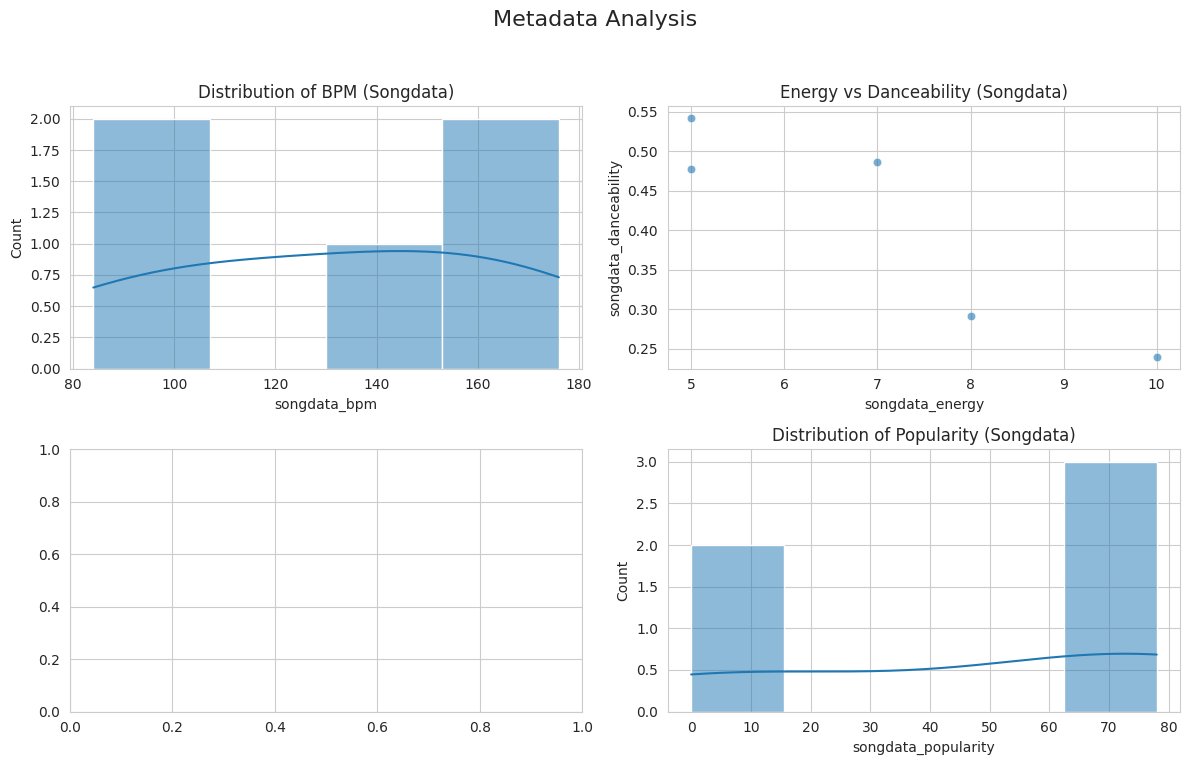

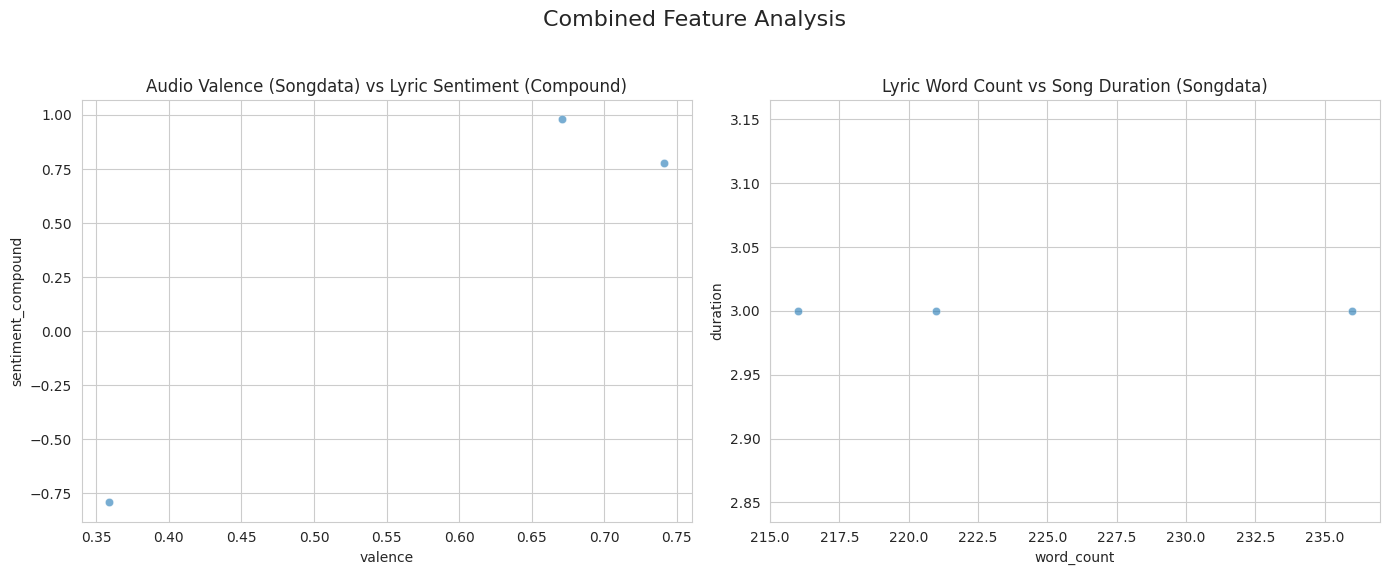

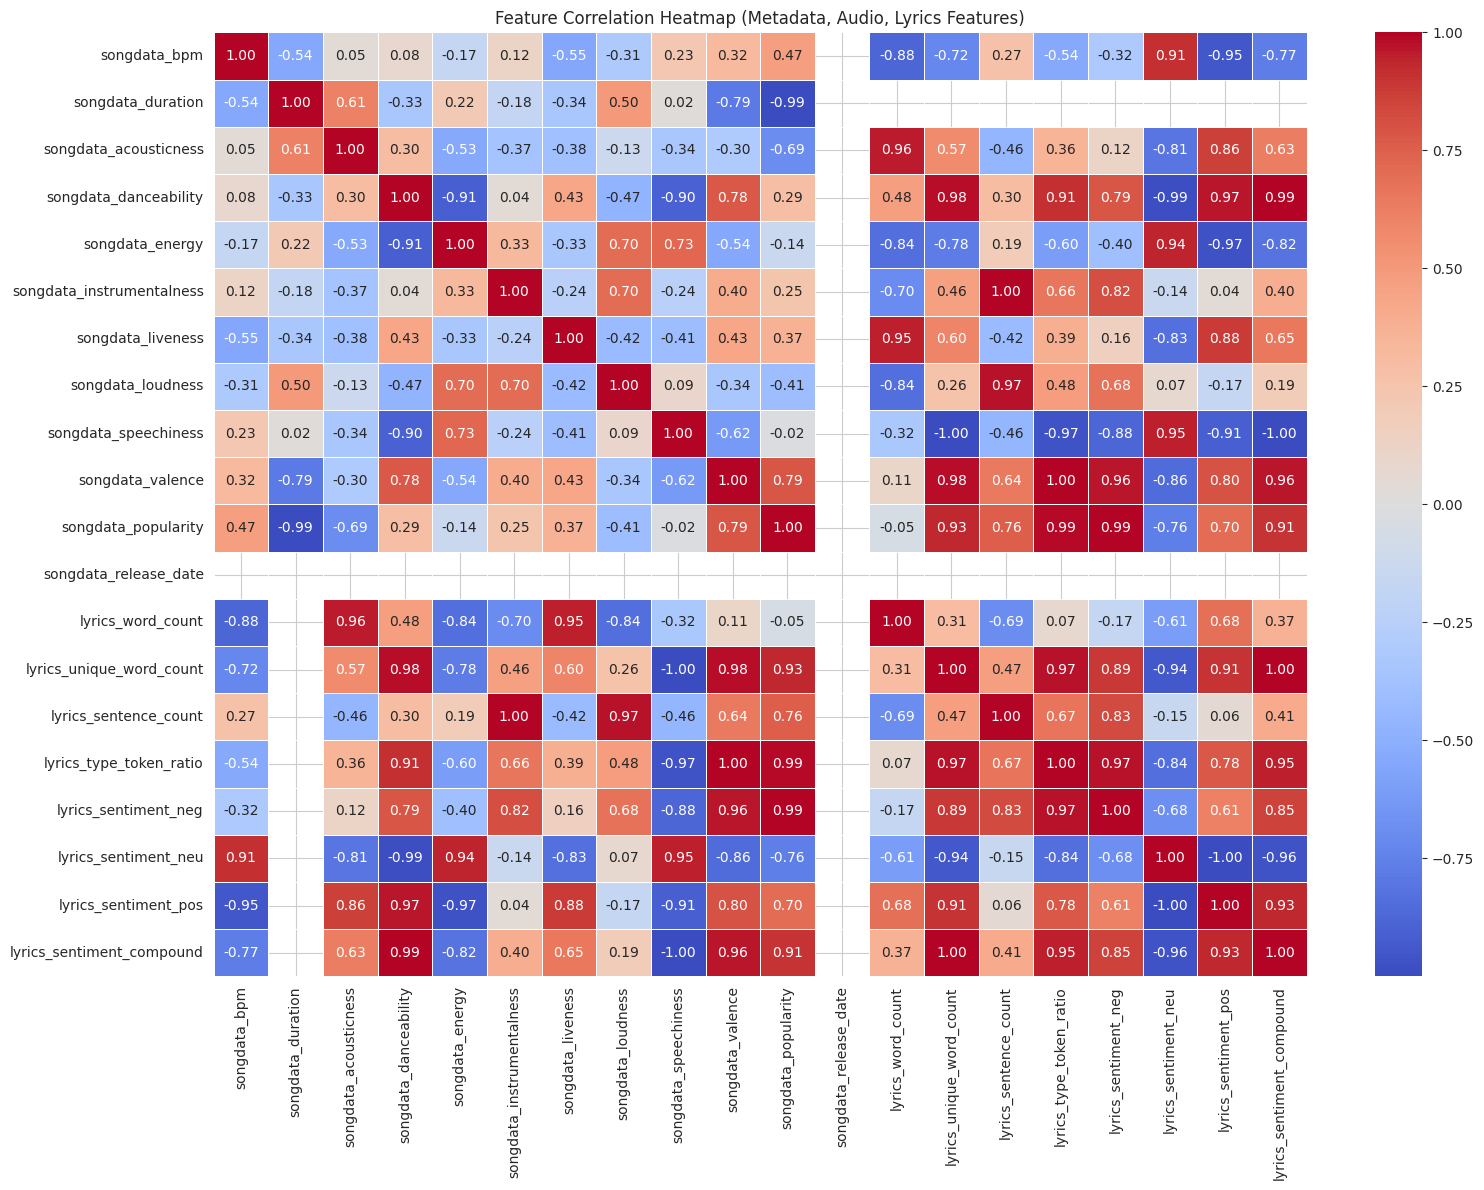

2025-04-21 04:04:43,036 - INFO - --- Data Analysis Complete ---



--- Script Execution Finished ---


In [7]:
import json
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import logging
import warnings
import traceback # Import traceback for detailed errors

# Try importing pydub; it's often needed by librosa for MP3s,
# or you can use it to convert MP3 to WAV before librosa.load
try:
    from pydub import AudioSegment
    logging.info("pydub imported successfully.")
except ImportError:
    logging.warning("pydub not found. Install with 'pip install pydub'. MP3 loading might fail without it or ffmpeg.")
    AudioSegment = None # Define AudioSegment as None if import fails

# Configure Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings('ignore', category=FutureWarning) # Suppress some future warnings from libraries

# Initialize NLTK VADER sentiment analyzer
analyzer = None
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    logging.warning("NLTK Vader lexicon not found. Attempting download...")
    try:
        nltk.download('vader_lexicon')
        logging.info("NLTK Vader lexicon downloaded.")
    except Exception as e:
        logging.error(f"Failed to download NLTK Vader lexicon: {e}. Sentiment analysis will be skipped.", exc_info=True)

try:
    analyzer = SentimentIntensityAnalyzer()
    logging.info("NLTK VADER SentimentIntensityAnalyzer initialized.")
except Exception as e:
    logging.error(f"Failed to initialize NLTK VADER SentimentIntensityAnalyzer: {e}. Sentiment analysis will be skipped.", exc_info=True)
    analyzer = None


# --- Helper Functions ---

def load_song_data_from_json(json_filepath: str) -> list:
    """Loads song data (full list of dictionaries) from a JSON file."""
    logging.info(f"Attempting to load JSON from: {json_filepath}")
    try:
        with open(json_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
            if isinstance(data, list):
                 logging.info(f"Successfully loaded {len(data)} entries from '{json_filepath}'.")
                 return data
            else:
                 logging.error(f"JSON data in '{json_filepath}' is not a list (found {type(data).__name__}).")
                 return [] # Return empty list if data is not a list

    except FileNotFoundError:
        logging.error(f"Error: JSON file not found at '{json_filepath}'")
        return [] # Return empty list on file not found
    except json.JSONDecodeError as e:
        logging.error(f"Error: Could not parse JSON file at '{json_filepath}': {e}")
        return [] # Return empty list on JSON parsing error
    except Exception as e:
        logging.error(f"An unexpected error occurred while reading '{json_filepath}': {e}", exc_info=True)
        return [] # Return empty list on other errors

# --- Modified flatten_songdata_info ---
def flatten_songdata_info(data_list):
    """
    Flattens the nested songdata_info into top-level keys and ensures
    other top-level keys like file_path and lyrics_file_path are included.
    """
    logging.info("Starting data flattening process.")
    flattened_data = []
    for i, item in enumerate(data_list):
        if not isinstance(item, dict):
             logging.warning(f"Skipping non-dictionary item at index {i} in JSON list: {item}")
             continue

        new_item = {}
        songdata_info = item.get('songdata_info', {}) # Safely get nested dict

        # Copy all original top-level keys first
        for key, value in item.items():
            # Skip the nested dict itself for now, handle its contents separately
            if key != 'songdata_info':
                 new_item[key] = value

        # Now add flattened songdata_info keys
        if isinstance(songdata_info, dict):
            for sd_key, sd_value in songdata_info.items():
                 # Add songdata keys, prefixing if necessary to avoid collision (though merge should handle this)
                 # Use the key name as is from the merged JSON output (e.g., songdata_bpm)
                 # Ensure we don't overwrite a top-level key if there's a name collision risk (less likely with good design)
                 new_item[f'songdata_{sd_key}'] = sd_value # Use f-string to construct the key name

        else:
            logging.warning(f"Expected 'songdata_info' for item {item.get('id', i)} to be a dict, but found {type(songdata_info).__name__}. Skipping songdata flattening for this item.")

        flattened_data.append(new_item)

    logging.info(f"Flattening complete. Produced {len(flattened_data)} items.")
    return flattened_data

def analyze_audio_file(audio_filepath):
    """Loads an audio file and extracts features using librosa."""
    # Ensure the file path is absolute or relative to the script's current working directory
    # The JSON contains paths like "downloads/Playlist Name/Song.mp3" which are relative
    # We need to ensure the script is run from the directory containing "downloads" or
    # adjust the path based on the JSON file's location. Assuming relative path from CWD.
    absolute_audio_filepath = os.path.abspath(audio_filepath)

    logging.debug(f"Attempting audio analysis for: {absolute_audio_filepath}")

    if not os.path.exists(absolute_audio_filepath):
        logging.warning(f"Audio file not found at path: {absolute_audio_filepath}. Skipping analysis.")
        return None

    try:
        # Librosa can often load MP3s directly if FFmpeg is installed and discoverable
        # If this fails, you might need to use pydub to convert to wav first:
        # Example using pydub:
        # if AudioSegment: # Check if pydub imported
        #     try:
        #         audio = AudioSegment.from_mp3(absolute_audio_filepath)
        #         # Create a temporary WAV file in a temp directory or same directory
        #         temp_wav_path = absolute_audio_filepath + ".temp.wav"
        #         audio.export(temp_wav_path, format="wav")
        #         y, sr = librosa.load(temp_wav_path, sr=None) # Load the temporary WAV
        #         os.remove(temp_wav_path) # Clean up the temporary file
        #     except Exception as e:
        #         logging.warning(f"pydub/ffmpeg conversion failed for {absolute_audio_filepath}: {e}")
        #         # Fallback to direct librosa load which might still work if ffmpeg is in PATH
        #         y, sr = librosa.load(absolute_audio_filepath, sr=None)
        # else: # pydub not available
        #     y, sr = librosa.load(absolute_audio_filepath, sr=None) # Try direct load


        # Simpler approach: Directly use librosa.load. It will use its installed backend (like ffmpeg)
        y, sr = librosa.load(absolute_audio_filepath, sr=None) # sr=None to preserve original sample rate

        logging.debug(f"Successfully loaded audio: shape={y.shape}, sr={sr}")

        # --- Feature Extraction ---
        duration = librosa.get_duration(y=y, sr=sr) if y is not None else np.nan

        # Handle potential issues with beat tracking on very short or silent files
        tempo = np.nan # Default to NaN if tempo detection fails
        try:
             # Only attempt beat tracking if audio loaded and duration is reasonable
             if y is not None and duration is not None and duration > 2: # Arbitrary duration threshold
                tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
                logging.debug(f"Calculated tempo: {tempo:.2f} BPM")
        except Exception:
             logging.debug(f"Tempo detection failed for {absolute_audio_filepath}.")


        # Calculate other features, handle cases where y might be empty after load issues
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)) if y is not None and y.size > 0 else np.nan
        energy = np.mean(librosa.feature.rmse(y=y)) if y is not None and y.size > 0 else np.nan

        # Compute MFCCs and take mean (handle case where y is too short)
        # Requires minimum audio length depending on n_fft, hop_length, and n_mfcc
        mfccs_mean = [np.nan] * 20 # Default MFCCs to NaN list
        if y is not None and y.size > (2048 + 512) * 2: # Rough minimum size estimate
            try:
                 mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
                 mfccs_mean = np.mean(mfccs, axis=1).tolist()
                 logging.debug(f"Calculated MFCCs mean: {mfccs_mean[:5]}...") # Log first few
            except Exception as e:
                 logging.debug(f"MFCC calculation failed for {absolute_audio_filepath}: {e}")


        audio_features = {
            'audio_duration_sec': duration,
            'audio_sample_rate': sr,
            'audio_tempo_bpm': tempo,
            'audio_spectral_centroid': spectral_centroid,
            'audio_energy_rmse': energy,
            'audio_mfcc_mean': mfccs_mean # Store as list
        }
        return audio_features

    except FileNotFoundError:
        # This block is technically redundant due to the os.path.exists check, but kept for clarity
        logging.warning(f"Audio file not found during librosa.load: {absolute_audio_filepath}. Skipping analysis.")
        return None
    except Exception as e:
        logging.error(f"Error during audio analysis for {absolute_audio_filepath}: {e}", exc_info=True)
        return None

def analyze_lyrics_file(lyrics_filepath):
    """Loads a lyrics file and extracts features using NLTK."""
    # Ensure the file path is absolute or relative to the script's current working directory
    # The JSON contains paths like ".../lyrics/Song.txt" which are relative
    # Assuming relative path from script's CWD.
    absolute_lyrics_filepath = os.path.abspath(lyrics_filepath)

    logging.debug(f"Attempting lyrics analysis for: {absolute_lyrics_filepath}")

    if not os.path.exists(absolute_lyrics_filepath):
        logging.warning(f"Lyrics file not found at path: {absolute_lyrics_filepath}. Skipping analysis.")
        return None

    try:
        with open(absolute_lyrics_filepath, 'r', encoding='utf-8') as f:
            lyrics_text = f.read()

        if not lyrics_text.strip():
            logging.warning(f"Lyrics file is empty or contains only whitespace: {absolute_lyrics_filepath}. Skipping analysis.")
            # Return a dictionary with default/zero values for features
            return {
                'lyrics_word_count': 0, 'lyrics_unique_word_count': 0, 'lyrics_sentence_count': 0,
                'lyrics_type_token_ratio': 0, 'lyrics_sentiment_neg': 0, 'lyrics_sentiment_neu': 0,
                'lyrics_sentiment_pos': 0, 'lyrics_sentiment_compound': 0
            }


        # --- Basic Text Processing ---
        words = nltk.word_tokenize(lyrics_text)
        sentences = nltk.sent_tokenize(lyrics_text)

        # Remove punctuation and convert to lowercase for word counts
        words_cleaned = [word.lower() for word in words if word.isalpha()]

        # --- Feature Extraction ---
        word_count = len(words_cleaned)
        unique_word_count = len(set(words_cleaned))
        sentence_count = len(sentences)
        type_token_ratio = (unique_word_count / word_count) if word_count > 0 else 0

        # Sentiment Analysis (using VADER)
        sentiment_scores = {'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0} # Default if analyzer is not available
        if analyzer:
             try:
                 sentiment_scores = analyzer.polarity_scores(lyrics_text)
             except Exception as e:
                  logging.warning(f"VADER sentiment analysis failed for {absolute_lyrics_filepath}: {e}")


        lyrics_features = {
            'lyrics_word_count': word_count,
            'lyrics_unique_word_count': unique_word_count,
            'lyrics_sentence_count': sentence_count,
            'lyrics_type_token_ratio': type_token_ratio,
            'lyrics_sentiment_neg': sentiment_scores['neg'],
            'lyrics_sentiment_neu': sentiment_scores['neu'],
            'lyrics_sentiment_pos': sentiment_scores['pos'],
            'lyrics_sentiment_compound': sentiment_scores['compound']
        }
        return lyrics_features

    except FileNotFoundError:
         # This block is technically redundant due to the os.path.exists check, but kept for clarity
        logging.warning(f"Lyrics file not found during read: {absolute_lyrics_filepath}. Skipping analysis.")
        return None
    except Exception as e:
        logging.error(f"Error during lyrics analysis for {absolute_lyrics_filepath}: {e}", exc_info=True)
        return None

# --- Main Analysis Function ---
def perform_analysis(json_filepath: str):
    """
    Performs analysis and visualization on the dataset from the JSON file,
    including analyzing linked audio and lyrics files.
    """
    logging.info("--- Starting Data Analysis ---")
    logging.info(f"Loading data from: {json_filepath}")

    # 1. Load Data
    all_song_data = load_song_data_from_json(json_filepath)
    if not all_song_data:
        logging.error("No song data loaded from JSON or JSON is empty/invalid. Analysis aborted.")
        return # Exit if loading fails

    # 2. Flatten Songdata Info and Create DataFrame
    flattened_song_data = flatten_songdata_info(all_song_data)

    # Create DataFrame. Pandas should automatically infer dtypes better now
    df = pd.DataFrame(flattened_song_data)

    # Ensure 'id' is numeric if it exists
    if 'id' in df.columns:
        df['id'] = pd.to_numeric(df['id'], errors='coerce')


    # 3. Audio Analysis & Add Features to DataFrame
    logging.info("\nStarting audio file analysis...")
    # Define audio feature columns to ensure they exist, initialize to NaN
    # Note: 'audio_mfcc_mean' is a list, pandas might store it as 'object'.
    audio_feature_cols = ['audio_duration_sec', 'audio_sample_rate', 'audio_tempo_bpm',
                          'audio_spectral_centroid', 'audio_energy_rmse', 'audio_mfcc_mean']
    for col in audio_feature_cols:
         if col not in df.columns:
             df[col] = np.nan # Initialize with NaN

    for index, row in df.iterrows():
        # Get the file_path which should be a relative path from the downloader script
        audio_file_path_relative = row.get('file_path')

        if audio_file_path_relative:
            # Analyze the audio file
            features = analyze_audio_file(audio_file_path_relative) # Pass relative path to analysis function

            if features:
                 # Add features directly to the DataFrame row
                 for key, value in features.items():
                      df.loc[index, key] = value # Use the key from the features dict (already prefixed)

            else:
                 logging.warning(f"Failed to extract audio features for '{row.get('spotify_song_name', 'Unknown')}' by '{row.get('spotify_artist_name', 'Unknown')}'. Corresponding columns for this row will be NaN.")

        else:
             logging.warning(f"Audio file path missing in JSON for index {index}. Skipping audio analysis for this entry.")


    # 4. Lyrics Analysis & Add Features to DataFrame
    logging.info("\nStarting lyrics analysis...")
    # Define lyrics feature columns to ensure they exist, initialize to NaN
    lyrics_feature_cols = ['lyrics_word_count', 'lyrics_unique_word_count', 'lyrics_sentence_count',
                           'lyrics_type_token_ratio', 'lyrics_sentiment_neg', 'lyrics_sentiment_neu',
                           'lyrics_sentiment_pos', 'lyrics_sentiment_compound']
    for col in lyrics_feature_cols:
         if col not in df.columns:
             df[col] = np.nan # Initialize with NaN


    for index, row in df.iterrows():
        # Get the lyrics_file_path which should be a relative path from the lyrics script
        lyrics_file_path_relative = row.get('lyrics_file_path')

        if lyrics_file_path_relative:
             # Analyze the lyrics file
             features = analyze_lyrics_file(lyrics_file_path_relative) # Pass relative path to analysis function

             if features:
                  # Add features directly to the DataFrame row
                  for key, value in features.items():
                       df.loc[index, key] = value # Use the key from the features dict (already prefixed)
             else:
                  logging.warning(f"Failed to extract lyrics features for '{row.get('spotify_song_name', 'Unknown')}' by '{row.get('spotify_artist_name', 'Unknown')}'. Corresponding columns for this row will be NaN.")
        else:
             logging.warning(f"Lyrics file path missing in JSON for index {index}. Skipping lyrics analysis for this entry.")


    # Convert relevant columns to numeric types again after adding features
    # Get all columns that might contain numeric data
    all_potential_numeric_cols = [col for col in df.columns if any(prefix in col for prefix in ['id', 'songdata_', 'audio_', 'lyrics_']) and col != 'audio_mfcc_mean']

    for col in all_potential_numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce') # Coerce errors to NaN

    # --- Perform Analysis and Visualizations using the final DataFrame 'df' ---
    logging.info("\nPerforming analysis and visualizations...")

    print("\nDataFrame Info after Analysis:")
    df.info()
    print("\nDataFrame Head after Analysis:")
    print(df.head())

    # Display descriptive statistics for all numeric columns that have data
    # Select only numeric columns that contain at least one non-NaN value
    numeric_cols_with_data = df.select_dtypes(include=np.number).dropna(axis=1, how='all').columns.tolist()
    # Exclude 'id' from description if desired, keep it in the list for plots/heatmap if needed
    descriptive_cols = [col for col in numeric_cols_with_data if col != 'id']

    if descriptive_cols:
        print("\nDescriptive Statistics for Numeric Features with Data:")
        print(df[descriptive_cols].describe())
    else:
        logging.warning("\nNo numeric columns with data available for descriptive statistics.")


    # --- Visualizations ---
    # Check if DataFrame has enough data points for plotting
    # Need at least two rows where the columns used for plotting are not NaN
    if df.shape[0] < 2:
         logging.warning("Not enough rows in the DataFrame for visualization.")
    else:
        try:
            sns.set_style("whitegrid")

            # Example 1: Metadata Visualizations (Histograms, Scatter)
            # Check if the DataFrame has data in the columns needed for this plot set
            metadata_plot_cols = ['songdata_bpm', 'songdata_energy', 'songdata_danceability', 'songdata_key', 'songdata_popularity']
            if any(col in df.columns and df[col].dropna().size > 0 for col in metadata_plot_cols):

                fig1, axes1 = plt.subplots(2, 2, figsize=(12, 8))
                fig1.suptitle("Metadata Analysis", fontsize=16)

                if 'songdata_bpm' in df.columns and df['songdata_bpm'].dropna().size > 0:
                    sns.histplot(df['songdata_bpm'].dropna(), kde=True, ax=axes1[0, 0])
                    axes1[0, 0].set_title("Distribution of BPM (Songdata)")

                if all(col in df.columns for col in ['songdata_energy', 'songdata_danceability']) and not df[['songdata_energy', 'songdata_danceability']].dropna().empty:
                    sns.scatterplot(data=df.dropna(subset=['songdata_energy', 'songdata_danceability']), x='songdata_energy', y='songdata_danceability', alpha=0.6, ax=axes1[0, 1])
                    axes1[0, 1].set_title("Energy vs Danceability (Songdata)")

                if 'songdata_key' in df.columns and df['songdata_key'].dropna().size > 0:
                    top_keys = df['songdata_key'].value_counts().nlargest(min(10, df['songdata_key'].nunique())) # Plot top 10 keys
                    if not top_keys.empty:
                        sns.barplot(x=top_keys.index, y=top_keys.values, palette="viridis", ax=axes1[1, 0])
                        axes1[1, 0].set_title("Top Keys (Songdata)")
                        axes1[1, 0].set_xlabel("Key")
                        axes1[1, 0].set_ylabel("Count")
                        plt.setp(axes1[1, 0].get_xticklabels(), rotation=45, ha="right") # Rotate labels
                    else:
                         axes1[1, 0].set_title("Top Keys (Songdata)")
                         axes1[1, 0].text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=axes1[1, 0].transAxes)


                if 'songdata_popularity' in df.columns and df['songdata_popularity'].dropna().size > 0:
                    sns.histplot(df['songdata_popularity'].dropna(), kde=True, bins=max(5, int(df['songdata_popularity'].dropna().nunique()/2)), ax=axes1[1, 1])
                    axes1[1, 1].set_title("Distribution of Popularity (Songdata)")

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                plt.show()
            else:
                 logging.warning("Not enough metadata columns with data for Metadata Analysis plots.")


            # Example 2: Combined Feature Visualizations (Scatter plots comparing features from different sources)
            # Define pairs of columns to plot, checking if they exist and have data below
            combined_plot_pairs = [
                ('songdata_bpm', 'audio_tempo_bpm', "Songdata BPM vs Calculated Audio Tempo"),
                ('songdata_energy', 'audio_energy_rmse', "Songdata Energy vs Audio Energy (RMSE)"),
                ('songdata_valence', 'lyrics_sentiment_compound', "Audio Valence (Songdata) vs Lyric Sentiment (Compound)"),
                ('lyrics_word_count', 'songdata_duration', "Lyric Word Count vs Song Duration (Songdata)")
            ]

            valid_combined_plots = [
                (x_col, y_col, title) for x_col, y_col, title in combined_plot_pairs
                if all(col in df.columns for col in [x_col, y_col]) and not df[[x_col, y_col]].dropna().empty
            ]

            if valid_combined_plots:
                 # Adjust figure size based on the number of plots
                 fig2, axes2 = plt.subplots(1, len(valid_combined_plots), figsize=(7 * len(valid_combined_plots), 6))
                 if len(valid_combined_plots) == 1:
                      axes2 = [axes2] # Ensure axes2 is a list if only one plot

                 fig2.suptitle("Combined Feature Analysis", fontsize=16)

                 for i, (x_col, y_col, title) in enumerate(valid_combined_plots):
                      sns.scatterplot(data=df.dropna(subset=[x_col, y_col]), x=x_col, y=y_col, alpha=0.6, ax=axes2[i])
                      axes2[i].set_title(title)
                      axes2[i].set_xlabel(x_col.replace('songdata_', '').replace('audio_', '').replace('lyrics_', '')) # Simple label cleaning
                      axes2[i].set_ylabel(y_col.replace('songdata_', '').replace('audio_', '').replace('lyrics_', ''))


                 plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                 plt.show()
            else:
                 logging.warning("Not enough data for Combined Feature scatter plots (requires data in pairs like BPM/Tempo, Valence/Sentiment, etc.).")


            # Example 3: Correlation Heatmap for All Numeric Features
            # Filter for columns that were successfully converted to numeric and have data
            plottable_numeric_cols = df.select_dtypes(include=np.number).dropna(axis=1, how='all').columns.tolist()
            # Exclude 'id' from the heatmap itself unless specifically desired
            heatmap_cols = [col for col in plottable_numeric_cols if col != 'id']


            if heatmap_cols and len(heatmap_cols) > 1: # Need at least 2 columns with data for a heatmap
                plt.figure(figsize=(max(8, len(heatmap_cols)*0.8), max(6, len(heatmap_cols)*0.6))) # Adjust figure size
                correlation_matrix_all = df[heatmap_cols].corr()
                sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
                plt.title("Feature Correlation Heatmap (Metadata, Audio, Lyrics Features)")
                plt.tight_layout()
                plt.show()
            else:
                 logging.warning("Not enough numeric columns with data for correlation heatmap.")

        except Exception as e:
             logging.error(f"An error occurred during visualization phase: {e}", exc_info=True)
             print(f"An error occurred during visualization: {e}")


    logging.info("--- Data Analysis Complete ---")


if __name__ == "__main__":
    print("--- Starting Data Analysis Script ---")
    print("This script analyzes data from a song_data.json file and linked audio/lyrics files.")
    print("Prerequisites:")
    print("1. Ensure you have run the previous data collection scripts to generate song_data.json, .mp3, and .txt files.")
    print("2. Ensure required Python libraries (pandas, numpy, matplotlib, seaborn, librosa, soundfile, pydub, nltk, scipy) are installed.")
    print("3. Ensure FFmpeg is installed and accessible in your system's PATH for audio analysis.")
    print("4. Ensure NLTK data (like 'vader_lexicon') is downloaded (run python and `nltk.download('vader_lexicon')`).")
    print("Usage: python your_analysis_script_name.py <path_to_song_data.json>")

    input_json_path = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/song_data.json"

    # Check if the provided path is a file and exists
    if not os.path.isfile(input_json_path):
        print(f"\nError: The provided path '{input_json_path}' is not a valid file or does not exist.")
        sys.exit(1)

    # Check if the JSON file is empty
    if os.path.getsize(input_json_path) == 0:
         logging.error(f"Input JSON file '{input_json_path}' is empty. Analysis aborted.")
         print(f"\nError: The provided JSON file '{input_json_path}' is empty. Please ensure the previous scripts ran correctly.")
         sys.exit(1)


    # --- Initiate Analysis ---
    perform_analysis(input_json_path)

    print("\n--- Script Execution Finished ---")

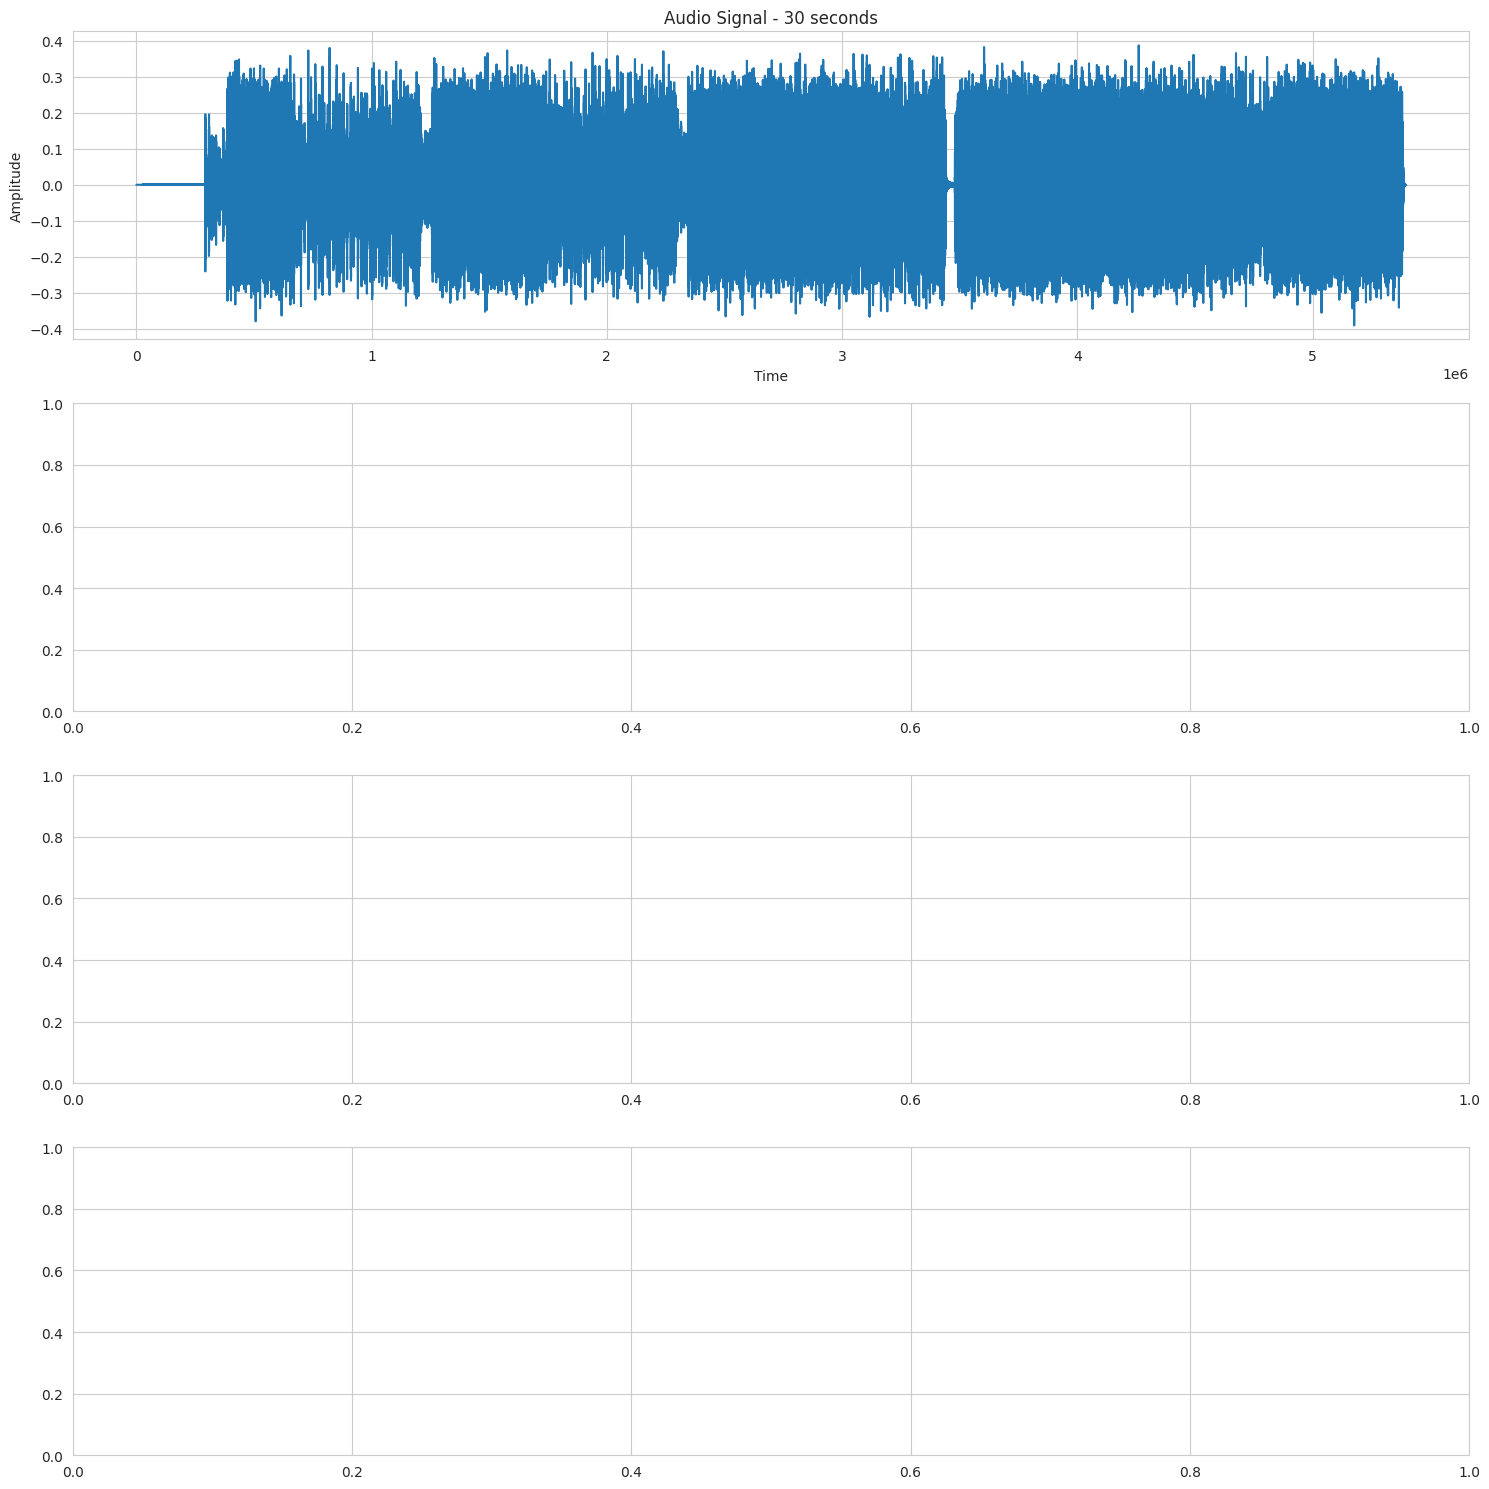

In [11]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

sound_sample_file = '/home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/Radiohead - Just.mp3'

# load sound file with librosa
signal, sample_rate = librosa.load(sound_sample_file)

#plot 30 second sample
fig, ax = plt.subplots(nrows=4, figsize=(15,15))
ax[0].set_title('Audio Signal - 30 seconds')
ax[0].set_ylabel('Amplitude')
ax[0].set_xlabel('Time')
ax[0].plot(range(len(signal)), signal)

plt.tight_layout()
plt.show()

Original audio loaded: Sample Rate = 44100, Duration = 244.69 seconds


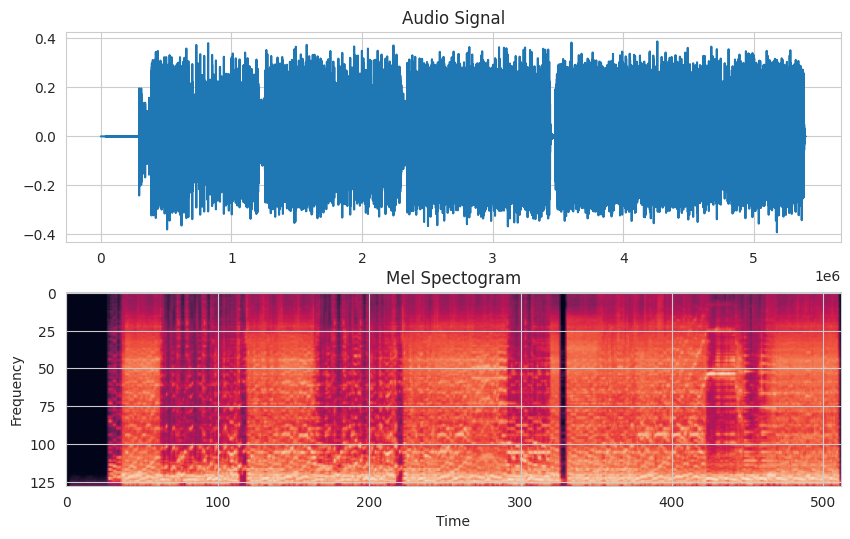

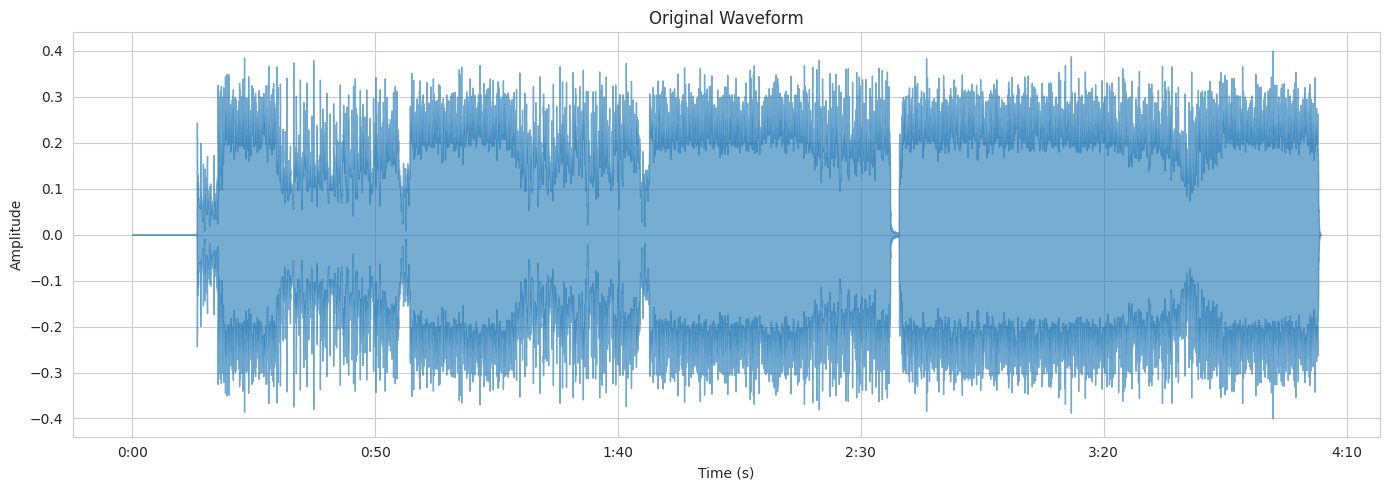

Trimmed audio duration: 231.04 seconds
Trimmed from index 584704 to 10773504


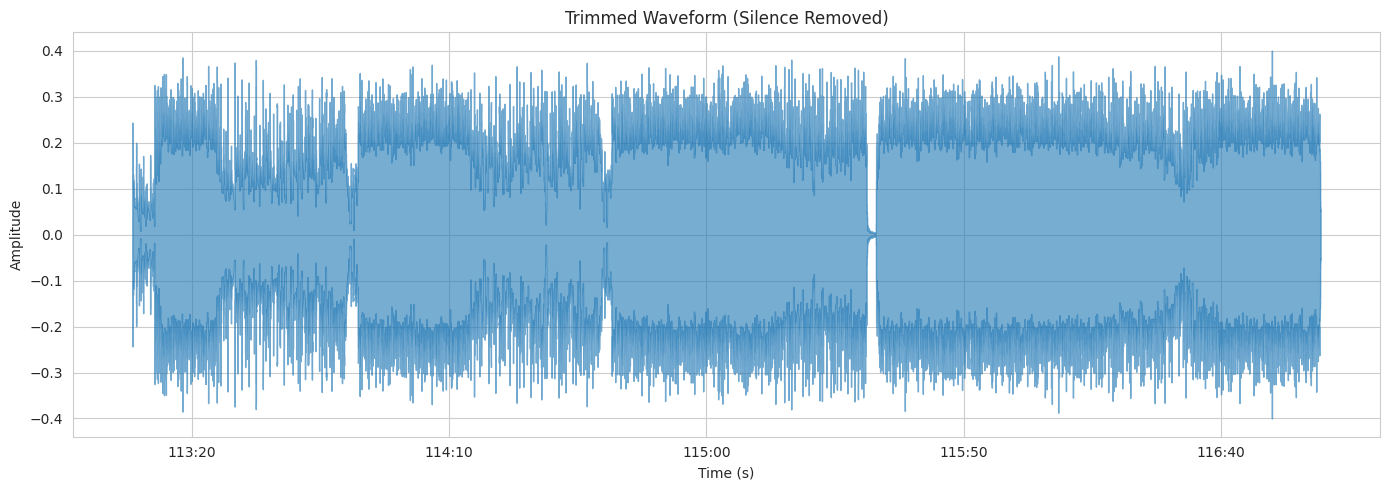

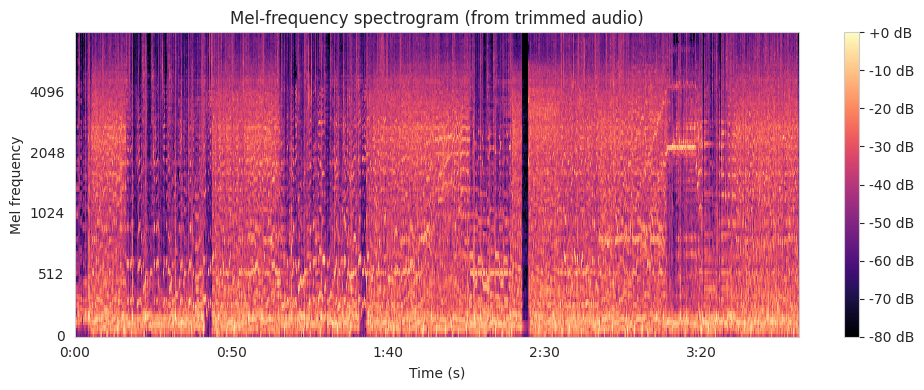

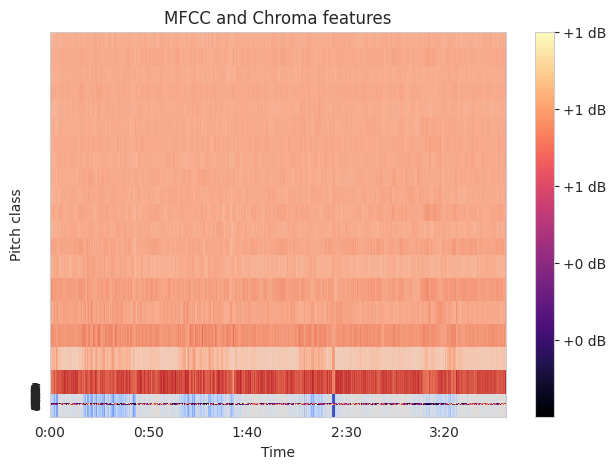

<Figure size 640x480 with 0 Axes>

In [16]:
from skimage.transform import resize

signal, sr = librosa.load(sound_sample_file)
    
mels = librosa.power_to_db(librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128, fmax=8000), ref=np.max)
mel_image = (((80+mels)/80)*255)
mel_image = np.flip(mel_image, axis=0)
mel_image = resize(mel_image, (128,512)).astype(np.uint8)

# mfcc = librosa.power_to_db(librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=128, fmax=8000), ref=np.max)
# mfcc_image = (((80+mfcc)/80)*255)
# mfcc_image = np.flip(mfcc_image, axis=0)
# mfcc_image = resize(mfcc_image, (128,512)).astype(np.uint8)

# chromagram = librosa.feature.chroma_cqt(y=signal, sr=sr)
# chroma_image = resize(chromagram*255, (128,512)).astype(np.uint8)

fig, ax = plt.subplots(nrows=2, figsize=(10,6))
ax[0].set_title('Audio Signal')
ax[0].plot(range(len(signal)), signal)
ax[1].set_title('Mel Spectogram')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Time')
ax[1].imshow(mel_image)
# ax[2].set_title('Mel Frequency Cepstral Coefficient')
# ax[2].imshow(mfcc_image)import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os # To check if file exists
# Import pydub if you need to load MP3s, as librosa often relies on it or ffmpeg
try:
    from pydub import AudioSegment
except ImportError:
    print("Warning: pydub not found. Install with 'pip install pydub' for better MP3 support.")

# Assume you have the path to an audio file from your song_data.json
audio_file_path = '/home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/Radiohead - Just.mp3' # Replace with an actual path from your JSON


if not os.path.exists(audio_file_path):
    print(f"Error: Audio file not found at {audio_file_path}")
else:
    try:
        # Load the audio file
        # Librosa needs FFmpeg to load MP3s. Ensure it's installed and in your PATH.
        y, sr = librosa.load(audio_file_path, sr=None) # Use sr=None to keep original sample rate

        print(f"Original audio loaded: Sample Rate = {sr}, Duration = {librosa.get_duration(y=y, sr=sr):.2f} seconds")

        # --- Visualize Original Waveform ---
        plt.figure(figsize=(14, 5))
        librosa.display.waveshow(y=y, sr=sr, alpha=0.6)
        plt.title('Original Waveform')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.tight_layout()
        plt.show()

        # --- Perform Silence Trimming ---
        # trim_threshold: amplitude threshold for silence detection
        # top_db: loudness threshold relative to peak (in dB)
        # Adjust these parameters based on your audio
        y_trimmed, index = librosa.effects.trim(y, top_db=20, frame_length=2048, hop_length=512)

        trimmed_duration = librosa.get_duration(y=y_trimmed, sr=sr)
        print(f"Trimmed audio duration: {trimmed_duration:.2f} seconds")
        print(f"Trimmed from index {index[0]} to {index[1]}")

        # --- Visualize Trimmed Waveform ---
        plt.figure(figsize=(14, 5))
        librosa.display.waveshow(y=y_trimmed, sr=sr, alpha=0.6, offset=librosa.frames_to_time(index[0], sr=sr)) # Offset x-axis for visualization
        plt.title('Trimmed Waveform (Silence Removed)')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.tight_layout()
        plt.show()

        # --- Generate and Visualize Mel Spectrogram from Trimmed Audio ---
        # You can use y_trimmed for feature extraction from here onwards
        n_mels = 128 # Number of Mel bands
        fmax = 8000 # Maximum frequency

        # Calculate Mel spectrogram from the trimmed audio signal
        M = librosa.feature.melspectrogram(y=y_trimmed, sr=sr, n_mels=n_mels, fmax=fmax)

        # Convert to decibel scale
        M_db = librosa.power_to_db(M, ref=np.max)

        # --- Visualize Mel Spectrogram ---
        plt.figure(figsize=(10, 4))
        # Display the spectrogram
        librosa.display.specshow(M_db, sr=sr, x_axis='time', y_axis='mel', fmax=fmax)
        plt.colorbar(format='%+2.0f dB')
        plt.title('Mel-frequency spectrogram (from trimmed audio)')
        plt.xlabel('Time (s)')
        plt.ylabel('Mel frequency')
        plt.tight_layout()
        plt.show()

        # --- Next Steps: Create Composite Image & Use Data Generator ---
        # If you need to create a composite image (Mel, MFCC, etc.)
        # Calculate other features from y_trimmed:
        mfccs = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=20)
        chroma = librosa.feature.chroma_stft(y=y_trimmed, sr=sr)
        # Convert to images
        mfcc_image = librosa.display.specshow(mfccs, sr=sr, x_axis='time', y_axis='mel', fmax=fmax)
        chroma_image = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma')
        plt.colorbar(format='%+2.0f dB')
        plt.title('MFCC and Chroma features')
        plt.tight_layout()
        plt.show()

        # Resize/Combine features as numpy arrays and save as an image file (e.g., PNG)
        # The resizing and image conversion code from your example snippet would go here
        # Remember to handle the time dimension inconsistency if features have different lengths
        # after processing (padding/trimming). Your code shows resizing to (128, 512).

        # Save the composite image to a directory (e.g., 'data/Spotify/comp_pngs/')
        # The path to this saved image would be used by your DataGenerator.


    except Exception as e:
        print(f"An error occurred during audio processing: {e}")
# ax[3].set_title('Chromagram')
# ax[3].imshow(chroma_image)
plt.tight_layout()
plt.show()

In [19]:
import json
import os
import sys
import librosa
import numpy as np
import matplotlib.pyplot as plt # Used for visualization during development, maybe keep for optional visual debug
import logging
import warnings
import traceback

# Try importing pydub; it's often needed by librosa for MP3s
try:
    from pydub import AudioSegment
    logging.info("pydub imported successfully.")
except ImportError:
    logging.warning("pydub not found. Install with 'pip install pydub'. MP3 loading might fail without it or ffmpeg.")
    AudioSegment = None

# Try importing scikit-image
try:
    from skimage.transform import resize
    logging.info("scikit-image imported successfully.")
except ImportError:
    logging.error("scikit-image not found. Install with 'pip install scikit-image'. Image resizing will fail.", exc_info=True)
    resize = None # Set to None if import fails

# Try importing Pillow (PIL)
try:
    from PIL import Image
    logging.info("Pillow imported successfully.")
except ImportError:
    logging.error("Pillow not found. Install with 'pip install Pillow'. Image saving will fail.", exc_info=True)
    Image = None


# Configure Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings('ignore', category=FutureWarning) # Suppress some future warnings from libraries

# --- Configuration ---
TARGET_HEIGHT = 128 # Target height for processed feature images
TARGET_WIDTH = 512  # Target width for processed feature images
IMAGE_OUTPUT_SUBDIR = "composite_images" # Subdirectory to save images within the playlist folder


# --- Helper Functions ---

def load_song_data_from_json(json_filepath: str) -> list:
    """Loads song data (full list of dictionaries) from a JSON file."""
    logging.info(f"Attempting to load JSON from: {json_filepath}")
    try:
        with open(json_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
            if isinstance(data, list):
                 logging.info(f"Successfully loaded {len(data)} entries from '{json_filepath}'.")
                 return data
            else:
                 logging.error(f"JSON data in '{json_filepath}' is not a list (found {type(data).__name__}).")
                 return []

    except FileNotFoundError:
        logging.error(f"Error: JSON file not found at '{json_filepath}'")
        return []
    except json.JSONDecodeError as e:
        logging.error(f"Error: Could not parse JSON file at '{json_filepath}': {e}")
        return []
    except Exception as e:
        logging.error(f"An unexpected error occurred while reading '{json_filepath}': {e}", exc_info=True)
        return []

def sanitize_filename(title: str) -> str:
    """Sanitizes string for use as a filename."""
    if not title:
        return "unknown"
    sanitized = re.sub(r'[<>:"/\\|?*]', '_', title)
    sanitized = re.sub(r'\s+', ' ', sanitized).strip()
    sanitized = re.sub(r'\.$', '', sanitized)
    return sanitized or "unknown"

def normalize_feature_array(feature_array: np.ndarray) -> np.ndarray:
    """Normalizes a NumPy array to the 0-1 range."""
    min_val = np.min(feature_array)
    max_val = np.max(feature_array)
    if max_val - min_val == 0:
        return np.zeros_like(feature_array) # Return zeros if array is constant
    return (feature_array - min_val) / (max_val - min_val)


# --- Core Processing Function ---

def generate_composite_image(audio_filepath: str, output_dir: str, song_info: dict, target_height: int, target_width: int) -> str | None:
    """
    Loads audio, trims silence, generates features, creates a composite image,
    and saves the image to the output directory.

    Args:
        audio_filepath: Absolute or relative path to the input audio file (.mp3).
        output_dir: The directory where the composite image should be saved.
        song_info: Dictionary containing song metadata (e.g., {'id': 1, 'spotify_song_name': 'Just', 'spotify_artist_name': 'Radiohead'}).
        target_height: The target height (feature dimension) for resized features.
        target_width: The target width (time dimension) for resized features and the final image.

    Returns:
        The relative path to the saved image file on success, None on failure.
    """
    if not os.path.exists(audio_filepath):
        logging.warning(f"Audio file not found at path: {audio_filepath}. Skipping image generation.")
        return None

    song_name = song_info.get('spotify_song_name', 'Unknown Song')
    artist_name = song_info.get('spotify_artist_name', 'Unknown Artist')
    song_id = song_info.get('id', 'NoID')

    logging.info(f"Processing audio for '{artist_name} - {song_name}' (ID: {song_id}) from {audio_filepath}")

    y = None
    sr = None

    try:
        # Load the audio file
        y, sr = librosa.load(audio_filepath, sr=None) # sr=None to preserve original sample rate
        logging.debug(f"Audio loaded. Shape: {y.shape if y is not None else 'None'}, SR: {sr}")

        if y is None or y.size == 0:
             logging.warning(f"Audio signal is empty after loading from {audio_filepath}. Skipping image generation.")
             return None

        # --- Optional: Silence Trimming ---
        # Adjust top_db as needed. Lower values are stricter about what is considered silence.
        try:
            y_trimmed, index = librosa.effects.trim(y, top_db=20)
            logging.debug(f"Audio trimmed. Original length: {len(y)}, Trimmed length: {len(y_trimmed)}")
            # Use trimmed audio for feature extraction
            y_process = y_trimmed
        except Exception as e:
             logging.warning(f"Silence trimming failed for {audio_filepath}: {e}. Using untrimmed audio.", exc_info=True)
             y_process = y # Fallback to untrimmed if trimming fails


        # --- Feature Extraction (Mel, MFCC, Chroma) from processed audio ---
        n_mfcc = 20
        n_chroma = 12

        try:
            # Mel Spectrogram
            M = librosa.feature.melspectrogram(y=y_process, sr=sr, n_mels=target_height, fmax=8000) # n_mels matches target height
            M_db = librosa.power_to_db(M, ref=np.max) # Convert to dB scale
            logging.debug(f"Mel Spectrogram shape: {M_db.shape}")

            # MFCCs
            # Ensure y_process is long enough for MFCC calculation with default settings
            if y_process.size > librosa.util.frame(y_process, frame_length=2048, hop_length=512).shape[0] * 512: # Rough check
                 mfccs = librosa.feature.mfcc(y=y_process, sr=sr, n_mfcc=n_mfcc)
                 logging.debug(f"MFCCs shape: {mfccs.shape}")
            else:
                 logging.warning(f"Audio too short for MFCC calculation for {audio_filepath}. Using dummy MFCCs.")
                 mfccs = np.zeros((n_mfcc, M_db.shape[1])) # Create dummy array with matching time dimension
                 # Need to fill with NaNs or handle appropriately if plotting/normalization expects specific ranges
                 # Let's use zeros for simplicity, normalization should handle it.


            # Chromagram (using CQT for potentially better pitch representation in music)
            try:
                 # Ensure y_process is long enough for CQT calculation
                 if y_process.size > librosa.cqt(y=y_process, sr=sr).shape[-1]: # Rough check
                    chromagram = librosa.feature.chroma_cqt(y=y_process, sr=sr, hop_length=512)
                    logging.debug(f"Chromagram shape: {chromagram.shape}")
                 else:
                     logging.warning(f"Audio too short for Chromagram calculation for {audio_filepath}. Using dummy Chromagram.")
                     chromagram = np.zeros((n_chroma, M_db.shape[1])) # Match time dimension
            except Exception as e:
                 logging.warning(f"Chromagram calculation failed for {audio_filepath}: {e}. Using dummy Chromagram.", exc_info=True)
                 chromagram = np.zeros((n_chroma, M_db.shape[1])) # Match time dimension


        except Exception as e:
             logging.error(f"Error during feature extraction for {audio_filepath}: {e}", exc_info=True)
             return None # Fail if feature extraction fails


        # --- Resize Feature Arrays to Target Dimensions ---
        # Ensure scikit-image is available
        if resize is None:
            logging.error("Scikit-image is not imported. Cannot resize features. Skipping image generation.")
            return None

        try:
            # Resize Mel Spectrogram (target_height x time_frames) -> (target_height x target_width)
            mel_resized = resize(M_db, (target_height, target_width), anti_aliasing=True)
            logging.debug(f"Mel resized shape: {mel_resized.shape}")

            # Resize MFCCs (n_mfcc x time_frames) -> (target_height x target_width)
            mfcc_resized = resize(mfccs, (target_height, target_width), anti_aliasing=True)
            logging.debug(f"MFCC resized shape: {mfcc_resized.shape}")

            # Resize Chromagram (n_chroma x time_frames) -> (target_height x target_width)
            chroma_resized = resize(chromagram, (target_height, target_width), anti_aliasing=True)
            logging.debug(f"Chroma resized shape: {chroma_resized.shape}")

        except Exception as e:
             logging.error(f"Error during feature resizing for {audio_filepath}: {e}", exc_info=True)
             return None


        # --- Normalize Feature Arrays to 0-1 Range ---
        try:
            mel_normalized = normalize_feature_array(mel_resized)
            mfcc_normalized = normalize_feature_array(mfcc_resized)
            chroma_normalized = normalize_feature_array(chroma_resized)
            logging.debug("Features normalized.")
        except Exception as e:
             logging.error(f"Error during feature normalization for {audio_filepath}: {e}", exc_info=True)
             return None


        # --- Stack Features into a Composite Image Array (Height, Width, Channels) ---
        # Assuming 3 channels: Mel, MFCC, Chroma
        try:
            composite_image_array = np.stack([mel_normalized, mfcc_normalized, chroma_normalized], axis=-1)
            logging.debug(f"Composite image array shape: {composite_image_array.shape}")
        except Exception as e:
             logging.error(f"Error stacking features into composite array for {audio_filepath}: {e}", exc_info=True)
             return None


        # --- Save Composite Image ---
        # Ensure Pillow is available
        if Image is None:
            logging.error("Pillow is not imported. Cannot save image. Skipping image generation.")
            return None

        try:
            # Convert the numpy array (float 0-1) to uint8 (0-255) for image saving
            composite_image_uint8 = (composite_image_array * 255).astype(np.uint8)

            # Create a PIL Image from the numpy array
            img = Image.fromarray(composite_image_uint8, 'RGB')

            # Define save path
            # Use song ID or sanitized name for the filename
            image_filename = f"{song_id}_{sanitize_filename(artist_name)}_{sanitize_filename(song_name)}.png"
            save_path_absolute = os.path.join(output_dir, image_filename)

            # Create output directory if it doesn't exist
            os.makedirs(output_dir, exist_ok=True)

            # Save the image
            img.save(save_path_absolute)

            # Return the path relative to the current working directory for consistency
            save_path_relative = os.path.relpath(save_path_absolute, os.getcwd())
            logging.info(f"Successfully generated and saved composite image to: {save_path_relative}")
            return save_path_relative

        except Exception as e:
            logging.error(f"Error saving composite image for {audio_filepath} to {save_path_absolute}: {e}", exc_info=True)
            return None

    except Exception as e:
        logging.error(f"An unexpected error occurred during processing audio file {audio_filepath}: {e}", exc_info=True)
        return None


# --- Main Execution Block ---

if __name__ == "__main__":
    print("--- Starting Composite Image Generation Script ---")
    print("This script generates composite feature images from audio files listed in a song_data.json.")
    print("Prerequisites:")
    print("1. Ensure the song_data.json file exists and contains valid 'file_path' entries pointing to MP3s.")
    print("2. Ensure required Python libraries (librosa, numpy, scikit-image, Pillow, pydub) are installed.")
    print("3. Ensure FFmpeg is installed and accessible in your system's PATH for audio loading.")
    print("Usage: python your_image_script_name.py <path_to_song_data.json>")


    input_json_path = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/song_data.json"

    # Check if the provided path is a file and exists
    if not os.path.isfile(input_json_path):
        print(f"\nError: The provided path '{input_json_path}' is not a valid file or does not exist.")
        sys.exit(1)

    # Check if the JSON file is empty
    if os.path.getsize(input_json_path) == 0:
         logging.error(f"Input JSON file '{input_json_path}' is empty. Script aborted.")
         print(f"\nError: The provided JSON file '{input_json_path}' is empty. Please ensure the previous scripts ran correctly.")
         sys.exit(1)

    # --- Load Song Data ---
    all_song_data = load_song_data_from_json(input_json_path)
    if not all_song_data:
        logging.error("No song data loaded from JSON. Script aborted.")
        print("\nError: No song data loaded from JSON. Please check the file content.")
        sys.exit(1)

    # --- Determine Output Directory ---
    # Place images in a subdirectory next to the JSON file
    json_base_dir = os.path.dirname(input_json_path)
    image_output_dir = os.path.join(json_base_dir, IMAGE_OUTPUT_SUBDIR)
    os.makedirs(image_output_dir, exist_ok=True)
    logging.info(f"Composite images will be saved to: {image_output_dir}")

    # --- Process Each Song ---
    processed_count = 0
    success_count = 0
    failed_count = 0

    for i, song_info in enumerate(all_song_data):
        processed_count += 1
        song_name = song_info.get('spotify_song_name', 'Unknown Song')
        artist_name = song_info.get('spotify_artist_name', 'Unknown Artist')
        song_id = song_info.get('id', i) # Use index if ID is missing
        audio_file_path_relative = song_info.get('file_path')

        if not audio_file_path_relative:
             logging.warning(f"[{processed_count}/{len(all_song_data)}] Audio file path missing for song ID {song_id}. Skipping.")
             failed_count += 1
             continue

        # Construct absolute path to the audio file
        # Assumes the 'file_path' in JSON is relative to the current working directory
        absolute_audio_filepath = os.path.abspath(audio_file_path_relative)

        # Generate and save the composite image
        saved_image_path = generate_composite_image(
            absolute_audio_filepath,
            image_output_dir,
            song_info,
            TARGET_HEIGHT,
            TARGET_WIDTH
        )

        if saved_image_path:
            success_count += 1
            # Optional: You could update the song_info dictionary with the image path here
            # song_info['composite_image_path'] = saved_image_path
            # However, saving back to JSON is NOT handled in this script for simplicity.
            # The next step (Data Generator) will need to find these images based on naming convention or directory scan.
        else:
            failed_count += 1
            logging.error(f"[{processed_count}/{len(all_song_data)}] Failed to generate composite image for '{artist_name} - {song_name}' (ID: {song_id}).")


    print("\n--- Composite Image Generation Complete ---")
    print(f"Processed {processed_count} songs.")
    print(f"Successfully generated images for {success_count} songs.")
    print(f"Failed to generate images for {failed_count} songs.")
    print(f"Images saved to: {image_output_dir}")
    print("Note: The song_data.json file was NOT updated by this script.")
    print("\n--- Script Execution Finished ---")

2025-04-21 04:26:40,739 - INFO - pydub imported successfully.
2025-04-21 04:26:40,741 - INFO - scikit-image imported successfully.
2025-04-21 04:26:40,742 - INFO - Pillow imported successfully.


2025-04-21 04:26:40,749 - INFO - Attempting to load JSON from: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/song_data.json
2025-04-21 04:26:40,752 - INFO - Successfully loaded 5 entries from '/home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/song_data.json'.
2025-04-21 04:26:40,754 - INFO - Composite images will be saved to: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/composite_images
2025-04-21 04:26:40,757 - WARNING - Audio file not found at path: /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/qw/Radiohead - Just.mp3. Skipping image generation.
2025-04-21 04:26:40,761 - ERROR - [1/5] Failed to generate composite image for 'Radiohead - Just' (ID: 1).
2025-04-21 04:26:40,764 - WARNING - Audio file not found at path: /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/qw/Sinatra (2005 Remaster).mp3. Skipping image generation.
2025-04-21 04:26:40,765 - ERROR - [2/5] Failed to generate composite image for 'Deftones - Sinatra - 

--- Starting Composite Image Generation Script ---
This script generates composite feature images from audio files listed in a song_data.json.
Prerequisites:
1. Ensure the song_data.json file exists and contains valid 'file_path' entries pointing to MP3s.
2. Ensure required Python libraries (librosa, numpy, scikit-image, Pillow, pydub) are installed.
3. Ensure FFmpeg is installed and accessible in your system's PATH for audio loading.
Usage: python your_image_script_name.py <path_to_song_data.json>

--- Composite Image Generation Complete ---
Processed 5 songs.
Successfully generated images for 0 songs.
Failed to generate images for 5 songs.
Images saved to: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/composite_images
Note: The song_data.json file was NOT updated by this script.

--- Script Execution Finished ---


In [21]:
import json
import os
import sys
import re
import logging
import warnings
import traceback
from pathlib import Path

import numpy as np
import librosa
# Optional for debug plots
import matplotlib.pyplot as plt

# Try importing pydub; it's often needed by librosa for MP3s
try:
    from pydub import AudioSegment
    logging.info("pydub imported successfully.")
except ImportError:
    logging.warning("pydub not found. Install with 'pip install pydub'. MP3 loading might fail without it or ffmpeg.")
    AudioSegment = None

# Try importing scikit-image
try:
    from skimage.transform import resize
    logging.info("scikit-image imported successfully.")
except ImportError:
    logging.error("scikit-image not found. Install with 'pip install scikit-image'. Image resizing will fail.", exc_info=True)
    resize = None

# Try importing Pillow (PIL)
try:
    from PIL import Image
    logging.info("Pillow imported successfully.")
except ImportError:
    logging.error("Pillow not found. Install with 'pip install Pillow'. Image saving will fail.", exc_info=True)
    Image = None

# Configure Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Configuration ---
TARGET_HEIGHT = 128
TARGET_WIDTH = 512
IMAGE_OUTPUT_SUBDIR = "composite_images"

# --- Helper Functions ---
def load_song_data_from_json(json_filepath: str) -> list:
    logging.info(f"Attempting to load JSON from: {json_filepath}")
    try:
        with open(json_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
            if isinstance(data, list):
                logging.info(f"Successfully loaded {len(data)} entries from '{json_filepath}'.")
                return data
            else:
                logging.error(f"JSON data in '{json_filepath}' is not a list (found {type(data).__name__}).")
                return []
    except FileNotFoundError:
        logging.error(f"Error: JSON file not found at '{json_filepath}'")
        return []
    except json.JSONDecodeError as e:
        logging.error(f"Error: Could not parse JSON file at '{json_filepath}': {e}")
        return []
    except Exception as e:
        logging.error(f"An unexpected error occurred while reading '{json_filepath}': {e}", exc_info=True)
        return []

def sanitize_filename(title: str) -> str:
    if not title:
        return "unknown"
    sanitized = re.sub(r'[<>:"/\\|?*]', '_', title)
    sanitized = re.sub(r'\s+', ' ', sanitized).strip()
    sanitized = re.sub(r'\.$', '', sanitized)
    return sanitized or "unknown"

def normalize_feature_array(arr: np.ndarray) -> np.ndarray:
    min_val, max_val = np.min(arr), np.max(arr)
    if max_val - min_val == 0:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

# --- Core Processing Function ---
def generate_composite_image(audio_filepath: str,
                             output_dir: str,
                             song_info: dict,
                             target_height: int,
                             target_width: int) -> str | None:
    if not os.path.exists(audio_filepath):
        logging.warning(f"Audio file not found at path: {audio_filepath}. Skipping image generation.")
        return None

    song_name = song_info.get('spotify_song_name', 'Unknown Song')
    artist_name = song_info.get('spotify_artist_name', 'Unknown Artist')
    song_id = song_info.get('id', 'NoID')

    logging.info(f"Processing '{artist_name} - {song_name}' (ID: {song_id})")

    try:
        y, sr = librosa.load(audio_filepath, sr=None)
        if y is None or y.size == 0:
            logging.warning(f"Loaded audio is empty for {audio_filepath}.")
            return None

        # Trim silence
        try:
            y, _ = librosa.effects.trim(y, top_db=20)
        except Exception:
            pass

        # Feature extraction
        M = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=target_height, fmax=8000)
        M_db = librosa.power_to_db(M, ref=np.max)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20) if y.size >= 2048 else np.zeros((20, M_db.shape[1]))
        try:
            chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=512)
        except Exception:
            chroma = np.zeros((12, M_db.shape[1]))

        # Resize
        if resize is None:
            return None
        mel_r = resize(M_db, (target_height, target_width), anti_aliasing=True)
        mfcc_r = resize(mfccs, (target_height, target_width), anti_aliasing=True)
        chroma_r = resize(chroma, (target_height, target_width), anti_aliasing=True)

        # Normalize
        mel_n = normalize_feature_array(mel_r)
        mfcc_n = normalize_feature_array(mfcc_r)
        chroma_n = normalize_feature_array(chroma_r)

        # Stack channels
        comp = np.stack([mel_n, mfcc_n, chroma_n], axis=-1)

        if Image is None:
            return None
        img = Image.fromarray((comp * 255).astype(np.uint8), 'RGB')

        os.makedirs(output_dir, exist_ok=True)
        fname = f"{song_id}_{sanitize_filename(artist_name)}_{sanitize_filename(song_name)}.png"
        save_path = os.path.join(output_dir, fname)
        img.save(save_path)
        logging.info(f"Saved image to: {save_path}")
        return os.path.relpath(save_path, os.getcwd())

    except Exception as e:
        logging.error(f"Error processing {audio_filepath}: {e}", exc_info=True)
        return None

# --- Main Execution Block ---
if __name__ == "__main__":
    print("--- Starting Composite Image Generation ---")
    input_json_path = sys.argv[1] if len(sys.argv) > 1 else None
    if not input_json_path or not os.path.isfile(input_json_path):
        print(f"Error: Provide a valid JSON path. Usage: python {sys.argv[0]} <song_data.json>")
        sys.exit(1)

    json_base_dir = os.path.dirname(os.path.abspath(input_json_path))
    data = load_song_data_from_json(input_json_path)
    if not data:
        sys.exit(1)

    image_output_dir = os.path.join(json_base_dir, IMAGE_OUTPUT_SUBDIR)

    processed = success = failed = 0
    for i, song in enumerate(data, 1):
        processed += 1
        raw = song.get('file_path', '')
        raw = raw.replace('%20', ' ')
        raw = raw.strip(' "\'\t\n')
        if not raw:
            logging.warning(f"Skipping empty path at index {i}")
            failed += 1
            continue

        path = (Path(json_base_dir) / raw).expanduser()
        try:
            path = path.resolve(strict=False)
        except Exception:
            path = path.absolute()
        audio_fp = str(path)

        saved = generate_composite_image(audio_fp, image_output_dir, song, TARGET_HEIGHT, TARGET_WIDTH)
        if saved:
            success += 1
        else:
            failed += 1

    print("\n--- Done ---")
    print(f"Processed: {processed}, Success: {success}, Failed: {failed}")
    print(f"Images are in: {image_output_dir}")


2025-04-21 04:40:47,402 - INFO - pydub imported successfully.


2025-04-21 04:40:47,403 - INFO - scikit-image imported successfully.
2025-04-21 04:40:47,404 - INFO - Pillow imported successfully.


--- Starting Composite Image Generation ---
Error: Provide a valid JSON path. Usage: python /home/psyph3ri0n/Documents/projects-2025/sur/venv/lib/python3.11/site-packages/ipykernel_launcher.py <song_data.json>


SystemExit: 1

/home/psyph3ri0n/Documents/projects-2025/sur/venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3675: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [23]:
import os
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path

# Configuration
AUDIO_DIR = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/qw/songs/"
SR = 22050
HOP_LENGTH = 512
WIN_LENGTH = 2048
TOP_DB = 30
N_MELS = 128

def extract_mel_db(audio_path: str):
    """Load audio, trim silence, and compute Mel spectrogram in dB."""
    y, sr = librosa.load(audio_path, sr=SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=TOP_DB)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=WIN_LENGTH, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    return librosa.power_to_db(mel, ref=None)

# Select a few example files to plot
audio_files = [
    f for f in os.listdir(AUDIO_DIR) if f.lower().endswith(".mp3")
]
sample_files = audio_files[:3]  # plot first 3 tracks

# Plot Mel spectrograms
for filename in sample_files:
    file_path = os.path.join(AUDIO_DIR, filename)
    mel_db = extract_mel_db(file_path)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mel_db, sr=SR, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Mel Spectrogram: {Path(filename).stem}")
    plt.tight_layout()
    plt.show()


TypeError: bad operand type for abs(): 'NoneType'